In [59]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor, plot_importance, DMatrix, train
from lightgbm import LGBMRegressor
import shap
import os
import fiona
from geopy.distance import geodesic

In [2]:
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
caserne = gpd.read_file("../data/caserne/2024_06_21_CIS.shp")
compagnies = gpd.read_file("../data/caserne/2024_06_21_Compagnies.shp")
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_2 = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")

In [3]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['duree_minutes'] = pd.to_timedelta(doubs_data['duree']).dt.total_seconds() / 60

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [4]:
caserne = caserne.to_crs(epsg=4326)
caserne["lon"] = caserne.geometry.x
caserne["lat"] = caserne.geometry.y

In [5]:
compagnies = compagnies.to_crs(epsg=4326)
print(compagnies.geometry.head())

0    POLYGON ((5.98589 47.33082, 5.98621 47.33091, ...
1    POLYGON ((6.37208 47.28665, 6.37036 47.28572, ...
2    POLYGON ((6.17776 47.01394, 6.17858 47.01315, ...
3    POLYGON ((6.29216 46.85959, 6.29174 46.85793, ...
4    MULTIPOLYGON (((6.35375 46.71830, 6.35262 46.7...
Name: geometry, dtype: geometry


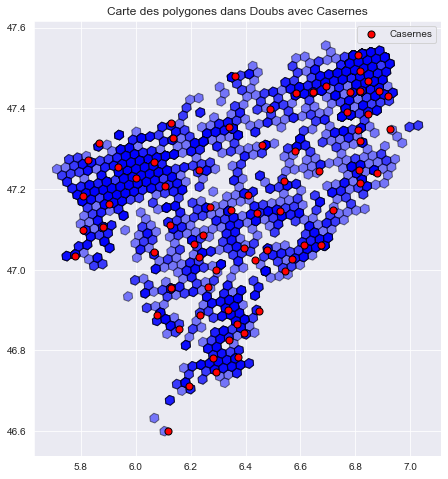

In [6]:
fig, ax = plt.subplots(figsize=(8,8))
doubs_data.plot(ax=ax, color="blue", edgecolor="black", alpha=0.5, label="Polygones (Doubs)")
caserne.plot(ax=ax, color="red", markersize=50, edgecolor="black", label="Casernes")
ax.set_title("Carte des polygones dans Doubs avec Casernes")
ax.legend()
plt.show()

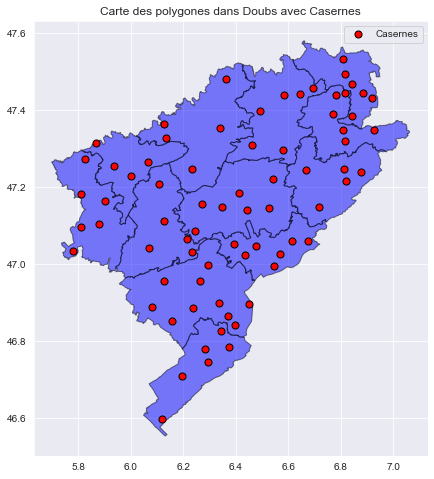

In [7]:
fig, ax = plt.subplots(figsize=(8,8))
compagnies.plot(ax=ax, color="blue", edgecolor="black", alpha=0.5, label="Polygones (Doubs)")
caserne.plot(ax=ax, color="red", markersize=50, edgecolor="black", label="Casernes")
ax.set_title("Carte des polygones dans Doubs avec Casernes")
ax.legend()
plt.show()

In [8]:
caserne['compagnie'] = caserne['compagnie'].replace('Maîche', 'Maiche')

In [9]:
firepoint = pd.concat([firepoint_1, firepoint_2, firepoint_3], ignore_index=True)
firepoint = firepoint.drop(columns=['geometry'], errors='ignore')

doubs_data = doubs_data.merge(firepoint, on='hex_id', how='left')

print(doubs_data.head())

            hex_id raison_sortie          date_debut            date_fin  \
0  871f820aaffffff      NATURELS 2014-10-02 14:08:53 2014-10-02 19:54:25   
1  871f82d61ffffff      NATURELS 2014-10-03 19:33:59 2014-10-03 19:55:31   
2  871f82d61ffffff      NATURELS 2014-10-04 19:24:49 2014-10-04 19:59:02   
3  871f82d4dffffff      NATURELS 2014-10-04 20:10:43 2014-10-04 20:42:34   
4  871f82700ffffff      NATURELS 2014-10-05 12:57:52 2014-10-05 13:24:24   

   label    year       date           departement  duree_minutes  \
0    1.0  2014.0 2014-10-02  departement-25-doubs     345.533333   
1    1.0  2014.0 2014-10-03  departement-25-doubs      21.533333   
2    1.0  2014.0 2014-10-04  departement-25-doubs      34.216667   
3    1.0  2014.0 2014-10-04  departement-25-doubs      31.850000   
4    1.0  2014.0 2014-10-05  departement-25-doubs      26.533333   

                                            geometry  ... water       tree  \
0  POLYGON ((6.21735 46.89696, 6.21925 46.88490, ...  ..

In [10]:
doubs_data = doubs_data.drop(columns=['date', 'departement', 'duree', 'centroid', 'scale0', 'sinister', 'date_debut', 'date_fin', 'raison_sortie', 'label', 'year'], errors='ignore')

Dimensions du DataFrame :
(2965, 51)

Info sur les types de données et les valeurs manquantes :
<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 2965 entries, 0 to 2964
Data columns (total 51 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   hex_id                 2965 non-null   object  
 1   duree_minutes          2965 non-null   float64 
 2   geometry               2965 non-null   geometry
 3   centroid_lon           2965 non-null   float64 
 4   centroid_lat           2965 non-null   float64 
 5   NDVI                   2679 non-null   float64 
 6   NDMI                   2679 non-null   float64 
 7   NDBI                   2679 non-null   float64 
 8   NDSI                   2679 non-null   float64 
 9   NDWI                   2679 non-null   float64 
 10  osmnx                  0 non-null      object  
 11  PasDeRoute             2679 non-null   float64 
 12  motorway               2679 non-null   flo

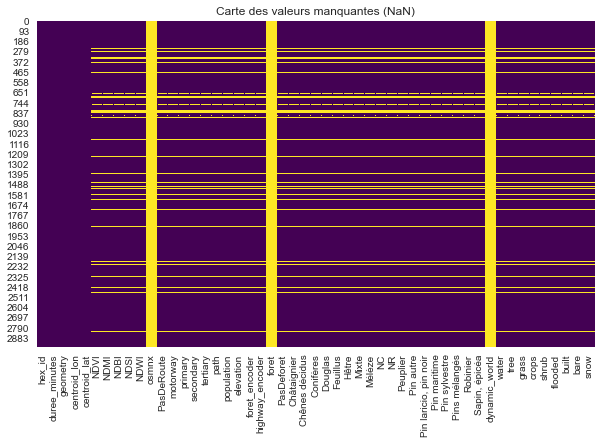


Nombre de valeurs manquantes (NaN) par colonne :
hex_id                      0
duree_minutes               0
geometry                    0
centroid_lon                0
centroid_lat                0
NDVI                      286
NDMI                      286
NDBI                      286
NDSI                      286
NDWI                      286
osmnx                    2965
PasDeRoute                286
motorway                  286
primary                   286
secondary                 286
tertiary                  286
path                      286
population                286
elevation                 286
foret_encoder             286
highway_encoder           286
foret                    2965
PasDeforet                286
Châtaignier               286
Chênes décidus            286
Conifères                 286
Douglas                   286
Feuillus                  286
Hêtre                     286
Mixte                     286
Mélèze                    286
NC                  

In [11]:
print("Dimensions du DataFrame :")
print(doubs_data.shape)

print("\nInfo sur les types de données et les valeurs manquantes :")
print(doubs_data.info())

plt.figure(figsize=(10, 6))
sns.heatmap(doubs_data.isnull(), cbar=False, cmap='viridis')
plt.title("Carte des valeurs manquantes (NaN)")
plt.show()

print("\nNombre de valeurs manquantes (NaN) par colonne :")
print(doubs_data.isnull().sum())

In [12]:
nan_percentage = doubs_data.isnull().mean() * 100

cols_to_keep = nan_percentage[nan_percentage <= 80].index

doubs_data = doubs_data[cols_to_keep]

print("\nDimensions du DataFrame après suppression des colonnes avec plus de 80% de NaN :")
print(doubs_data.shape)

print("\nColonnes restantes après nettoyage :")
print(doubs_data.columns)


Dimensions du DataFrame après suppression des colonnes avec plus de 80% de NaN :
(2965, 48)

Colonnes restantes après nettoyage :
Index(['hex_id', 'duree_minutes', 'geometry', 'centroid_lon', 'centroid_lat',
       'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway',
       'primary', 'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow'],
      dtype='object')


In [13]:
doubs_data = doubs_data.dropna()

print("\nVérification des NaN après suppression des lignes dans doubs_data :")
print(doubs_data.isnull().sum())

print("\nDimensions du DataFrame doubs_data après suppression des NaN :")
print(doubs_data.shape)


Vérification des NaN après suppression des lignes dans doubs_data :
hex_id                   0
duree_minutes            0
geometry                 0
centroid_lon             0
centroid_lat             0
NDVI                     0
NDMI                     0
NDBI                     0
NDSI                     0
NDWI                     0
PasDeRoute               0
motorway                 0
primary                  0
secondary                0
tertiary                 0
path                     0
population               0
elevation                0
foret_encoder            0
highway_encoder          0
PasDeforet               0
Châtaignier              0
Chênes décidus           0
Conifères                0
Douglas                  0
Feuillus                 0
Hêtre                    0
Mixte                    0
Mélèze                   0
NC                       0
NR                       0
Peuplier                 0
Pin autre                0
Pin laricio, pin noir    0
Pin maritime 

In [14]:
doubs_data.columns

Index(['hex_id', 'duree_minutes', 'geometry', 'centroid_lon', 'centroid_lat',
       'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway',
       'primary', 'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow'],
      dtype='object')

In [15]:
geometry = doubs_data[['hex_id', 'geometry']].drop_duplicates(subset='hex_id').set_index('hex_id')

doubs_data = doubs_data.groupby('hex_id').agg(
    {
        'duree_minutes': ['mean', 'max', 'min', 'std'],
        'centroid_lon': 'mean',
        'centroid_lat': 'mean',
        'NDVI': 'mean',
        'NDMI': 'mean',
        'NDBI': 'mean',
        'NDSI': 'mean',
        'NDWI': 'mean',
        'PasDeRoute': 'mean',
        'motorway': 'mean',
        'primary': 'mean',
        'secondary': 'mean',
        'tertiary': 'mean',
        'path': 'mean',
        'population': 'mean',
        'elevation': 'mean',
        'foret_encoder': 'mean',
        'highway_encoder': 'mean',
        'PasDeforet': 'mean',
        'Châtaignier': 'mean',
        'Chênes décidus': 'mean',
        'Conifères': 'mean',
        'Douglas': 'mean',
        'Feuillus': 'mean',
        'Hêtre': 'mean',
        'Mixte': 'mean',
        'Mélèze': 'mean',
        'NC': 'mean',
        'NR': 'mean',
        'Peuplier': 'mean',
        'Pin autre': 'mean',
        'Pin laricio, pin noir': 'mean',
        'Pin maritime': 'mean',
        'Pin sylvestre': 'mean',
        'Pins mélangés': 'mean',
        'Robinier': 'mean',
        'Sapin, épicéa': 'mean',
        'water': 'mean',
        'tree': 'mean',
        'grass': 'mean',
        'crops': 'mean',
        'shrub': 'mean',
        'flooded': 'mean',
        'built': 'mean',
        'bare': 'mean',
        'snow': 'mean',
    }
).reset_index()

doubs_data.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in doubs_data.columns.values]

doubs_data = gpd.GeoDataFrame(doubs_data.merge(geometry, left_on='hex_id_', right_index=True), geometry='geometry')

print(doubs_data.head())

           hex_id_  duree_minutes_mean  duree_minutes_max  duree_minutes_min  \
0  871f80492ffffff          117.325000         197.783333          40.850000   
1  871f80493ffffff           79.483333         126.966667          32.000000   
2  871f80498ffffff          160.133333         160.133333         160.133333   
3  871f8049affffff           65.383333          65.383333          65.383333   
4  871f8049cffffff           89.400000          89.400000          89.400000   

   duree_minutes_std  centroid_lon_mean  centroid_lat_mean  NDVI_mean  \
0          66.540232           6.350198          47.477082   0.720443   
1          67.151574           6.381746          47.480996   0.739361   
2                NaN           6.444873          47.488800   0.785204   
3                NaN           6.431903          47.468880   0.778036   
4                NaN           6.426270          47.504821   0.751272   

   NDMI_mean  NDBI_mean  ...  water_mean  tree_mean  grass_mean  crops_mean  \
0

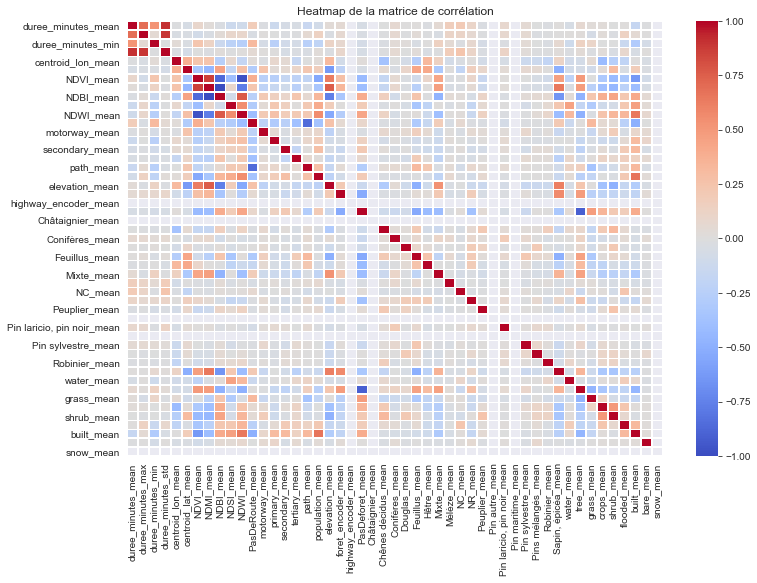

In [16]:
corr_matrix = doubs_data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.6)
plt.title("Heatmap de la matrice de corrélation")
plt.show()

In [17]:
correlation_threshold = 0.9

correlated_features = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > correlation_threshold:
            colname = corr_matrix.columns[i]
            correlated_features.add(colname)

print("Features trop corrélées à supprimer :", correlated_features)

Features trop corrélées à supprimer : {'duree_minutes_std', 'tree_mean', 'NDWI_mean', 'NDBI_mean'}


In [18]:
doubs_data = doubs_data.drop(columns=correlated_features)

print("Dataset après suppression des features trop corrélées :", doubs_data.shape)

Dataset après suppression des features trop corrélées : (627, 47)


In [19]:
type(doubs_data)

geopandas.geodataframe.GeoDataFrame

In [20]:
print(doubs_data.columns)

Index(['hex_id_', 'duree_minutes_mean', 'duree_minutes_max',
       'duree_minutes_min', 'centroid_lon_mean', 'centroid_lat_mean',
       'NDVI_mean', 'NDMI_mean', 'NDSI_mean', 'PasDeRoute_mean',
       'motorway_mean', 'primary_mean', 'secondary_mean', 'tertiary_mean',
       'path_mean', 'population_mean', 'elevation_mean', 'foret_encoder_mean',
       'highway_encoder_mean', 'PasDeforet_mean', 'Châtaignier_mean',
       'Chênes décidus_mean', 'Conifères_mean', 'Douglas_mean',
       'Feuillus_mean', 'Hêtre_mean', 'Mixte_mean', 'Mélèze_mean', 'NC_mean',
       'NR_mean', 'Peuplier_mean', 'Pin autre_mean',
       'Pin laricio, pin noir_mean', 'Pin maritime_mean', 'Pin sylvestre_mean',
       'Pins mélangés_mean', 'Robinier_mean', 'Sapin, épicéa_mean',
       'water_mean', 'grass_mean', 'crops_mean', 'shrub_mean', 'flooded_mean',
       'built_mean', 'bare_mean', 'snow_mean', 'geometry'],
      dtype='object')


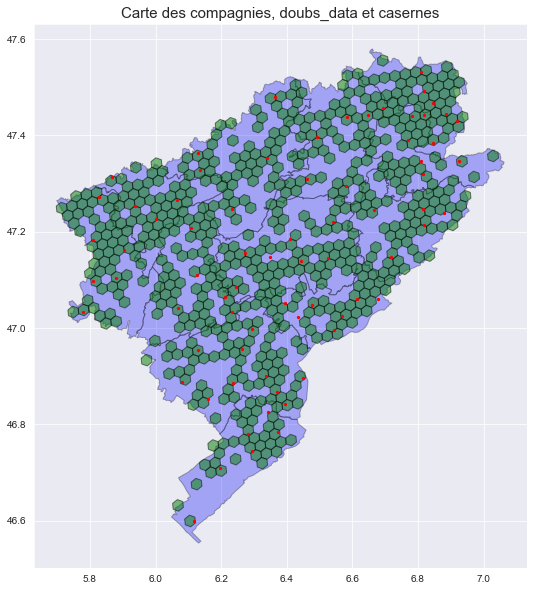

In [21]:
fig, ax = plt.subplots(figsize=(10, 10))

compagnies.plot(ax=ax, color='blue', alpha=0.3, edgecolor='black')

doubs_data.plot(ax=ax, color='green', alpha=0.5, edgecolor='black')

caserne.plot(ax=ax, color='red', marker='o', markersize=5)

ax.set_title("Carte des compagnies, doubs_data et casernes", fontsize=15)

plt.show()

In [22]:
doubs_data['id_compagnie'] = None

for idx, hexagone in doubs_data.iterrows():
    intersecting_companies = compagnies[compagnies.intersects(hexagone['geometry'])]

    if len(intersecting_companies) == 1:
        doubs_data.at[idx, 'id_compagnie'] = intersecting_companies.iloc[0]['id']
    elif len(intersecting_companies) > 1:
        max_area = 0
        best_company_id = None
        for _, company in intersecting_companies.iterrows():
            intersection = hexagone['geometry'].intersection(company['geometry'])
            area = intersection.area
            if area > max_area:
                max_area = area
                best_company_id = company['id']

        doubs_data.at[idx, 'id_compagnie'] = best_company_id

doubs_data.head()

,hex_id_,duree_minutes_mean,duree_minutes_max,duree_minutes_min,centroid_lon_mean,centroid_lat_mean,NDVI_mean,NDMI_mean,NDSI_mean,PasDeRoute_mean,...,water_mean,grass_mean,crops_mean,shrub_mean,flooded_mean,built_mean,bare_mean,snow_mean,geometry,id_compagnie
0,871f80492ffffff,117.325000,197.783333,40.850000,6.350198,47.477082,0.720443,0.145452,-0.593620,96.116627,...,0.012568,25.637803,0.062838,4.700264,0.000000,1.156215,0.0,0.0,"POLYGON ((6.33348 47.48111, 6.33537 47.46913, ...",2.0
1,871f80493ffffff,79.483333,126.966667,32.000000,6.381746,47.480996,0.739361,0.162564,-0.599609,95.966830,...,0.000000,11.056665,0.175901,4.611132,0.037693,3.982912,0.0,0.0,"POLYGON ((6.36503 47.48503, 6.36691 47.47305, ...",2.0
2,871f80498ffffff,160.133333,160.133333,160.133333,6.444873,47.488800,0.785204,0.193932,-0.627573,97.701871,...,0.000000,4.633932,0.012558,0.000000,0.000000,0.000000,0.0,0.0,"POLYGON ((6.42815 47.49284, 6.43003 47.48086, ...",10.0
3,871f8049affffff,65.383333,65.383333,65.383333,6.431903,47.468880,0.778036,0.189057,-0.623016,96.609318,...,0.000000,15.509230,0.226045,0.653020,0.012558,2.687429,0.0,0.0,"POLYGON ((6.41518 47.47292, 6.41706 47.46094, ...",2.0
4,871f8049cffffff,89.400000,89.400000,89.400000,6.426270,47.504821,0.751272,0.175163,-0.599002,96.231629,...,0.050245,26.692627,0.037684,0.565256,0.012561,3.052380,0.0,0.0,"POLYGON ((6.40954 47.50886, 6.41142 47.49688, ...",2.0


In [23]:
casernes_without_compagnie = caserne[caserne['compagnie'].isnull()]

if not casernes_without_compagnie.empty:
    print("Les casernes suivantes n'ont pas de compagnie associée :")
    print(casernes_without_compagnie[['id', 'compagnie']])
else:
    print("Toutes les casernes ont une compagnie associée.")

Toutes les casernes ont une compagnie associée.


In [24]:
casernes_invalides = caserne[~caserne['compagnie'].isin(compagnies['nom'])]

if not casernes_invalides.empty:
    print("Les casernes suivantes ont une compagnie qui n'est pas présente dans le dataframe 'compagnies' :")
    print(casernes_invalides[['id_pg', 'compagnie']])
else:
    print("Toutes les casernes ont une compagnie valide présente dans le dataframe 'compagnies'.")

Toutes les casernes ont une compagnie valide présente dans le dataframe 'compagnies'.


In [25]:
caserne = caserne.merge(compagnies[['id', 'nom']], left_on='compagnie', right_on='nom', how='left')

caserne = caserne.rename(columns={'id': 'id_compagnie'})

if 'nom' in caserne.columns:
    caserne = caserne.drop(columns=['nom'])

none_count = caserne['id_compagnie'].isna().sum()
print(f"Nombre de casernes sans id_compagnie : {none_count}")

print(caserne[['compagnie', 'id_compagnie']].head())

Nombre de casernes sans id_compagnie : 0
         compagnie  id_compagnie
0         Besançon           1.0
1  Baume-les-Dames           2.0
2      Montbéliard           6.0
3       Pontarlier           4.0
4      Montbéliard           6.0


In [26]:
if 'nom_y' in caserne.columns:
    caserne = caserne.drop(columns=['nom_y'])

print(caserne.head())

    id_pg                    sous_type cs_cod               nom_x  \
0  840642  Centre de Secours Principal  25155        BESANCON EST   
1  840674            Centre de Secours  25706     PREMIER PLATEAU   
2  840713                          CPI  25703  PLATEAU DE BLAMONT   
3  840644  Centre de Secours Principal  25462          PONTARLIER   
4  840712                          CPI  25004         ABBEVILLERS   

         compagnie                  geometry       lon        lat  \
0         Besançon  POINT (6.06536 47.26571)  6.065359  47.265714   
1  Baume-les-Dames  POINT (6.23181 47.24656)  6.231807  47.246561   
2      Montbéliard  POINT (6.84404 47.38538)  6.844042  47.385383   
3       Pontarlier  POINT (6.33503 46.89990)  6.335031  46.899903   
4      Montbéliard  POINT (6.91975 47.42989)  6.919745  47.429894   

   id_compagnie  
0           1.0  
1           2.0  
2           6.0  
3           4.0  
4           6.0  


In [27]:
if doubs_data.crs != caserne.crs:
    caserne = caserne.to_crs(doubs_data.crs)

def trouver_caserne_proche(hex_row):
    casernes_meme_compagnie = caserne[caserne['id_compagnie'] == hex_row['id_compagnie']]

    if casernes_meme_compagnie.empty:
        return pd.Series([None, None])

    casernes_meme_compagnie = casernes_meme_compagnie.copy()
    casernes_meme_compagnie['distance'] = casernes_meme_compagnie['geometry'].distance(hex_row['geometry'])

    caserne_proche = casernes_meme_compagnie.loc[casernes_meme_compagnie['distance'].idxmin()]

    return pd.Series([caserne_proche['id_pg'], caserne_proche['distance']])

doubs_data[['id_caserne_proche', 'distance_caserne']] = doubs_data.apply(trouver_caserne_proche, axis=1)

print("Nombre d'hexagones sans caserne attribuée :", doubs_data['id_caserne_proche'].isna().sum())

print(doubs_data[['hex_id_', 'id_caserne_proche', 'distance_caserne']].head())

Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



Nombre d'hexagones sans caserne attribuée : 0
           hex_id_ id_caserne_proche  distance_caserne
0  871f80492ffffff            840668          0.000000
1  871f80493ffffff            840668          0.003200
2  871f80498ffffff            840675          0.090886
3  871f8049affffff            840668          0.053004
4  871f8049cffffff            840668          0.051726


In [28]:
caserne['id_compagnie'] = caserne['id_compagnie'].astype('category')

In [29]:
RADIUS = 5000

doubs_data = doubs_data.to_crs(epsg=2154)
caserne = caserne.to_crs(epsg=2154)

def closest_caserne(row):
    casernes_meme_compagnie = caserne[caserne['id_compagnie'] == row['id_compagnie']]
    if casernes_meme_compagnie.empty:
        return None, None

    casernes_meme_compagnie['distance'] = casernes_meme_compagnie['geometry'].distance(row['geometry'])
    closest = casernes_meme_compagnie.loc[casernes_meme_compagnie['distance'].idxmin()]
    return closest['id_pg'], closest['distance']

doubs_data[['closest_caserne', 'distance_closest_caserne']] = doubs_data.apply(closest_caserne, axis=1, result_type='expand')

def count_casernes(row):
    return caserne[caserne.distance(row.geometry) < RADIUS].shape[0]

doubs_data['num_casernes_5km'] = doubs_data.apply(count_casernes, axis=1)

def avg_distance_casernes(row):
    nearby = caserne[caserne.distance(row.geometry) < RADIUS]
    if nearby.empty:
        return np.nan
    return nearby.distance(row.geometry).mean()

doubs_data['mean_distance_casernes_5km'] = doubs_data.apply(avg_distance_casernes, axis=1)

doubs_data['access_autoroute'] = doubs_data['primary_mean']
doubs_data['access_nationale'] = doubs_data['secondary_mean']
doubs_data['access_locale'] = doubs_data['tertiary_mean']

doubs_data['accessibilite_globale'] = (
    doubs_data['primary_mean'] * 3 +
    doubs_data['secondary_mean'] * 2 +
    doubs_data['tertiary_mean'] * 1
) / 6

doubs_data['densite_urbaine'] = doubs_data['population_mean'] * doubs_data['built_mean']

doubs_data['forêt_difficile'] = (doubs_data['foret_encoder_mean'] > 0.5).astype(int)
doubs_data['altitude'] = doubs_data['elevation_mean']

compagnie_size = caserne.groupby('id_compagnie').agg(taille_compagnie=('id_compagnie', 'count')).reset_index()
doubs_data = doubs_data.merge(compagnie_size[['id_compagnie', 'taille_compagnie']], on='id_compagnie', how='left')

doubs_data['ratio_pop_casernes'] = doubs_data['population_mean'] / (doubs_data['num_casernes_5km'] + 1)

doubs_data = doubs_data.to_crs(epsg=4326)

print("Ajout des nouvelles features terminé ! ✅")
doubs_data.head()

Ajout des nouvelles features terminé ! ✅


,hex_id_,duree_minutes_mean,duree_minutes_max,duree_minutes_min,centroid_lon_mean,centroid_lat_mean,NDVI_mean,NDMI_mean,NDSI_mean,PasDeRoute_mean,...,mean_distance_casernes_5km,access_autoroute,access_nationale,access_locale,accessibilite_globale,densite_urbaine,forêt_difficile,altitude,taille_compagnie,ratio_pop_casernes
0,871f80492ffffff,117.325000,197.783333,40.850000,6.350198,47.477082,0.720443,0.145452,-0.593620,96.116627,...,0.000000,0.703783,0.0,2.249592,0.726823,27.749180,0,146.408066,5,12.000012
1,871f80493ffffff,79.483333,126.966667,32.000000,6.381746,47.480996,0.739361,0.162564,-0.599609,95.966830,...,242.573393,0.238723,0.0,3.166227,0.647066,3.983003,0,179.104370,5,0.500011
2,871f80498ffffff,160.133333,160.133333,160.133333,6.444873,47.488800,0.785204,0.193932,-0.627573,97.701871,...,NaN,0.000000,0.0,2.159990,0.359998,0.000000,1,207.098419,6,46.999943
3,871f8049affffff,65.383333,65.383333,65.383333,6.431903,47.468880,0.778036,0.189057,-0.623016,96.609318,...,4030.708664,0.000000,0.0,3.265101,0.544184,2.687513,0,204.256683,5,0.500016
4,871f8049cffffff,89.400000,89.400000,89.400000,6.426270,47.504821,0.751272,0.175163,-0.599002,96.231629,...,4138.857555,0.000000,0.0,1.796257,0.299376,18.314378,0,200.414795,5,3.000016


In [30]:
doubs_data.columns

Index(['hex_id_', 'duree_minutes_mean', 'duree_minutes_max',
       'duree_minutes_min', 'centroid_lon_mean', 'centroid_lat_mean',
       'NDVI_mean', 'NDMI_mean', 'NDSI_mean', 'PasDeRoute_mean',
       'motorway_mean', 'primary_mean', 'secondary_mean', 'tertiary_mean',
       'path_mean', 'population_mean', 'elevation_mean', 'foret_encoder_mean',
       'highway_encoder_mean', 'PasDeforet_mean', 'Châtaignier_mean',
       'Chênes décidus_mean', 'Conifères_mean', 'Douglas_mean',
       'Feuillus_mean', 'Hêtre_mean', 'Mixte_mean', 'Mélèze_mean', 'NC_mean',
       'NR_mean', 'Peuplier_mean', 'Pin autre_mean',
       'Pin laricio, pin noir_mean', 'Pin maritime_mean', 'Pin sylvestre_mean',
       'Pins mélangés_mean', 'Robinier_mean', 'Sapin, épicéa_mean',
       'water_mean', 'grass_mean', 'crops_mean', 'shrub_mean', 'flooded_mean',
       'built_mean', 'bare_mean', 'snow_mean', 'geometry', 'id_compagnie',
       'id_caserne_proche', 'distance_caserne', 'closest_caserne',
       'distance

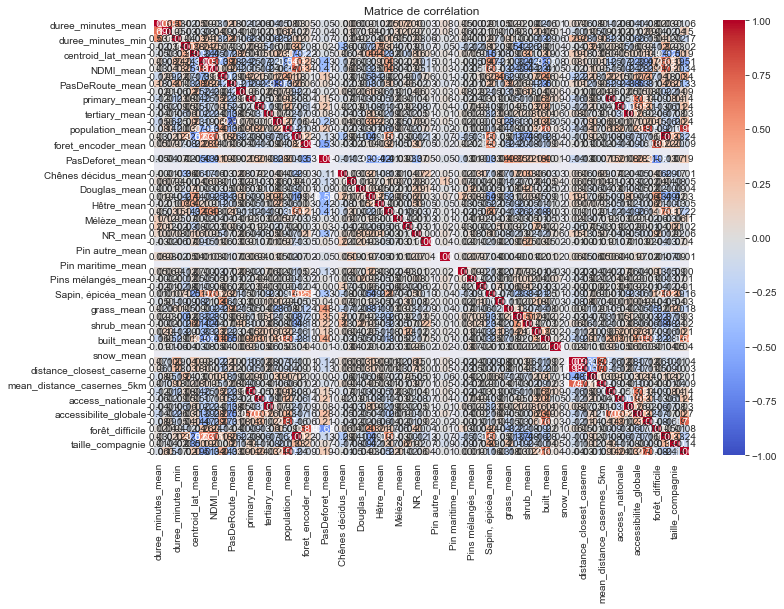

Colonnes supprimées : ['distance_closest_caserne', 'access_autoroute', 'access_nationale', 'access_locale', 'altitude', 'ratio_pop_casernes']
Nouveau DataFrame avec 57 features.


In [31]:
corr_matrix = doubs_data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matrice de corrélation")
plt.show()

threshold = 0.9
corr_matrix_abs = corr_matrix.abs()
upper_triangle = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]

doubs_data = doubs_data.drop(columns=to_drop)

print(f"Colonnes supprimées : {to_drop}")
print(f"Nouveau DataFrame avec {doubs_data.shape[1]} features.")

In [32]:
doubs_data.columns

Index(['hex_id_', 'duree_minutes_mean', 'duree_minutes_max',
       'duree_minutes_min', 'centroid_lon_mean', 'centroid_lat_mean',
       'NDVI_mean', 'NDMI_mean', 'NDSI_mean', 'PasDeRoute_mean',
       'motorway_mean', 'primary_mean', 'secondary_mean', 'tertiary_mean',
       'path_mean', 'population_mean', 'elevation_mean', 'foret_encoder_mean',
       'highway_encoder_mean', 'PasDeforet_mean', 'Châtaignier_mean',
       'Chênes décidus_mean', 'Conifères_mean', 'Douglas_mean',
       'Feuillus_mean', 'Hêtre_mean', 'Mixte_mean', 'Mélèze_mean', 'NC_mean',
       'NR_mean', 'Peuplier_mean', 'Pin autre_mean',
       'Pin laricio, pin noir_mean', 'Pin maritime_mean', 'Pin sylvestre_mean',
       'Pins mélangés_mean', 'Robinier_mean', 'Sapin, épicéa_mean',
       'water_mean', 'grass_mean', 'crops_mean', 'shrub_mean', 'flooded_mean',
       'built_mean', 'bare_mean', 'snow_mean', 'geometry', 'id_compagnie',
       'id_caserne_proche', 'distance_caserne', 'closest_caserne',
       'num_case

In [33]:
cols_to_drop = [
    'duree_minutes_max', 'duree_minutes_min',
    'centroid_lon_mean', 'mean_distance_casernes_5km', 'geometry',
    'hex_id_', 'id_compagnie', 'id_caserne_proche', 'closest_caserne'
]

doubs_data = doubs_data.drop(columns=cols_to_drop, errors="ignore")

print(doubs_data.head())
print(doubs_data.info())

   duree_minutes_mean  centroid_lat_mean  NDVI_mean  NDMI_mean  NDSI_mean  \
0          117.325000          47.477082   0.720443   0.145452  -0.593620   
1           79.483333          47.480996   0.739361   0.162564  -0.599609   
2          160.133333          47.488800   0.785204   0.193932  -0.627573   
3           65.383333          47.468880   0.778036   0.189057  -0.623016   
4           89.400000          47.504821   0.751272   0.175163  -0.599002   

   PasDeRoute_mean  motorway_mean  primary_mean  secondary_mean  \
0        96.116627            0.0      0.703783             0.0   
1        95.966830            0.0      0.238723             0.0   
2        97.701871            0.0      0.000000             0.0   
3        96.609318            0.0      0.000000             0.0   
4        96.231629            0.0      0.000000             0.0   

   tertiary_mean  ...  flooded_mean  built_mean  bare_mean  snow_mean  \
0       2.249592  ...      0.000000    1.156215        0.0   

In [34]:
y = doubs_data["duree_minutes_mean"]
X = doubs_data.drop(columns=["duree_minutes_mean"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Taille du dataset d'entraînement :", X_train.shape)
print("Taille du dataset de test :", X_test.shape)

Taille du dataset d'entraînement : (501, 47)
Taille du dataset de test : (126, 47)


In [35]:
xgb_model = XGBRegressor(objective="reg:squarederror", random_state=42)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")

MAE : 37.585
RMSE : 50.559


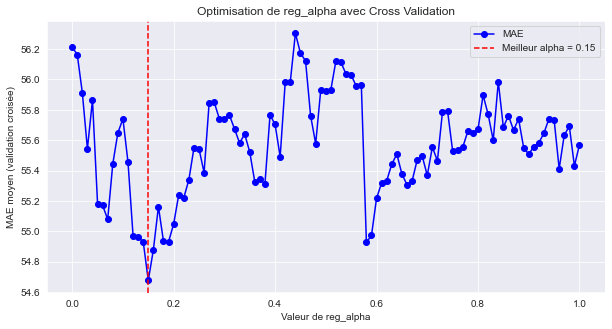

Meilleur alpha : 0.15 avec un MAE de 54.676


In [36]:
alpha_values = np.arange(0, 1.01, 0.01)
mae_scores = []

for alpha in alpha_values:
    xgb_model = XGBRegressor(objective="reg:squarederror", reg_alpha=alpha, random_state=42)
    scores = cross_val_score(xgb_model, X_train, y_train, scoring="neg_mean_absolute_error", cv=5)
    mae_scores.append(-scores.mean())

best_alpha = alpha_values[np.argmin(mae_scores)]
best_mae = min(mae_scores)

plt.figure(figsize=(10,5))
plt.plot(alpha_values, mae_scores, marker="o", linestyle="-", color="b", label="MAE")
plt.axvline(x=best_alpha, color="r", linestyle="--", label=f"Meilleur alpha = {best_alpha:.2f}")
plt.xlabel("Valeur de reg_alpha")
plt.ylabel("MAE moyen (validation croisée)")
plt.title("Optimisation de reg_alpha avec Cross Validation")
plt.legend()
plt.show()

print(f"Meilleur alpha : {best_alpha:.2f} avec un MAE de {best_mae:.3f}")

In [37]:
# Réentraîner XGBoost avec le meilleur alpha trouvé
xgb_model_best = XGBRegressor(objective="reg:squarederror", reg_alpha=0.15, random_state=42)
xgb_model_best.fit(X_train, y_train)

# Prédictions sur le test set
y_pred_best = xgb_model_best.predict(X_test)

# Évaluation
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print(f"MAE avec alpha=0.15 : {mae_best:.3f}")
print(f"RMSE avec alpha=0.15 : {rmse_best:.3f}")

MAE avec alpha=0.15 : 37.187
RMSE avec alpha=0.15 : 50.570


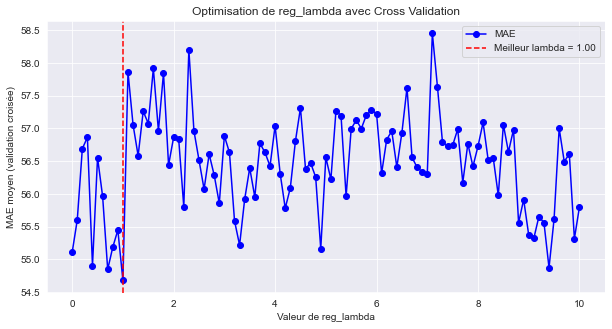

Meilleur lambda : 1.00 avec un MAE de 54.676


In [62]:
lambda_values = np.arange(0, 10.1, 0.1)
mae_scores_lambda = []

for reg_lambda in lambda_values:
    xgb_model = XGBRegressor(objective="reg:squarederror", reg_alpha=0.15, reg_lambda=reg_lambda, random_state=42)
    scores = cross_val_score(xgb_model, X_train, y_train, scoring="neg_mean_absolute_error", cv=5)
    mae_scores_lambda.append(-scores.mean())  # Cross_val_score retourne une valeur négative

best_lambda = lambda_values[np.argmin(mae_scores_lambda)]
best_mae_lambda = min(mae_scores_lambda)

plt.figure(figsize=(10,5))
plt.plot(lambda_values, mae_scores_lambda, marker="o", linestyle="-", color="b", label="MAE")
plt.axvline(x=best_lambda, color="r", linestyle="--", label=f"Meilleur lambda = {best_lambda:.2f}")
plt.xlabel("Valeur de reg_lambda")
plt.ylabel("MAE moyen (validation croisée)")
plt.title("Optimisation de reg_lambda avec Cross Validation")
plt.legend()
plt.show()

print(f"Meilleur lambda : {best_lambda:.2f} avec un MAE de {best_mae_lambda:.3f}")

In [41]:
xgb_model_tuned = XGBRegressor(objective="reg:squarederror", reg_alpha=0.15, reg_lambda=0.72, random_state=42)
xgb_model_tuned.fit(X_train, y_train)

y_pred_tuned = xgb_model_tuned.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print(f"MAE avec alpha=0.15 et lambda=0.72 : {mae_tuned:.3f}")
print(f"RMSE avec alpha=0.15 et lambda=0.72 : {rmse_tuned:.3f}")

MAE avec alpha=0.15 et lambda=0.72 : 40.490
RMSE avec alpha=0.15 et lambda=0.72 : 56.728


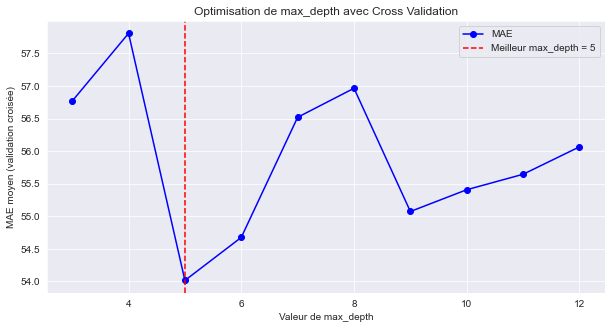

Meilleur max_depth : 5 avec un MAE de 54.015


In [42]:
depth_values = range(3, 13)
mae_scores_depth = []

for depth in depth_values:
    xgb_model = XGBRegressor(objective="reg:squarederror", reg_alpha=0.15, reg_lambda=1, max_depth=depth, random_state=42)
    scores = cross_val_score(xgb_model, X_train, y_train, scoring="neg_mean_absolute_error", cv=5)
    mae_scores_depth.append(-scores.mean())

best_depth = depth_values[np.argmin(mae_scores_depth)]
best_mae_depth = min(mae_scores_depth)

plt.figure(figsize=(10,5))
plt.plot(depth_values, mae_scores_depth, marker="o", linestyle="-", color="b", label="MAE")
plt.axvline(x=best_depth, color="r", linestyle="--", label=f"Meilleur max_depth = {best_depth}")
plt.xlabel("Valeur de max_depth")
plt.ylabel("MAE moyen (validation croisée)")
plt.title("Optimisation de max_depth avec Cross Validation")
plt.legend()
plt.show()

print(f"Meilleur max_depth : {best_depth} avec un MAE de {best_mae_depth:.3f}")


In [46]:
xgb_model_tuned = XGBRegressor(
    objective="reg:squarederror",
    reg_alpha=0.15,
    reg_lambda=1,
    max_depth=5,
    random_state=42
)
xgb_model_tuned.fit(X_train, y_train)

y_pred_tuned = xgb_model_tuned.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print(f"MAE avec max_depth=5 : {mae_tuned:.3f}")
print(f"RMSE avec max_depth=5 : {rmse_tuned:.3f}")

MAE avec max_depth=5 : 38.005
RMSE avec max_depth=5 : 52.849


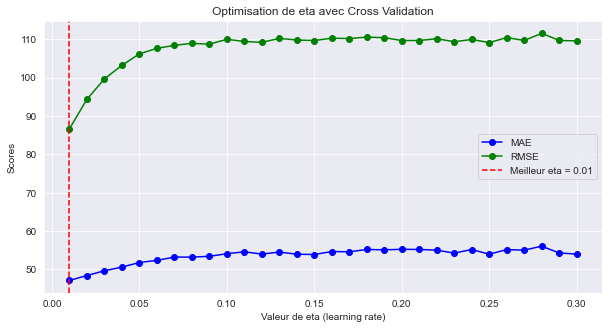

Meilleur eta : 0.01 avec un MAE de 47.146 et un RMSE de 86.661


In [48]:
eta_values = np.arange(0.01, 0.31, 0.01)
mae_scores_eta = []
rmse_scores_eta = []

for eta in eta_values:
    xgb_model = XGBRegressor(
        objective="reg:squarederror",
        reg_alpha=0.15,
        reg_lambda=1,
        max_depth=5,
        learning_rate=eta,
        random_state=42
    )
    scores_mae = cross_val_score(xgb_model, X_train, y_train, scoring="neg_mean_absolute_error", cv=5)
    scores_rmse = cross_val_score(xgb_model, X_train, y_train, scoring="neg_root_mean_squared_error", cv=5)

    mae_scores_eta.append(-scores_mae.mean())
    rmse_scores_eta.append(-scores_rmse.mean())

best_eta = eta_values[np.argmin(mae_scores_eta)]
best_mae_eta = min(mae_scores_eta)
best_rmse_eta = min(rmse_scores_eta)

plt.figure(figsize=(10,5))
plt.plot(eta_values, mae_scores_eta, marker="o", linestyle="-", color="b", label="MAE")
plt.plot(eta_values, rmse_scores_eta, marker="o", linestyle="-", color="g", label="RMSE")
plt.axvline(x=best_eta, color="r", linestyle="--", label=f"Meilleur eta = {best_eta:.2f}")
plt.xlabel("Valeur de eta (learning rate)")
plt.ylabel("Scores")
plt.title("Optimisation de eta avec Cross Validation")
plt.legend()
plt.show()

print(f"Meilleur eta : {best_eta:.2f} avec un MAE de {best_mae_eta:.3f} et un RMSE de {best_rmse_eta:.3f}")

In [49]:
xgb_model_tuned = XGBRegressor(
    objective="reg:squarederror",
    reg_alpha=0.15,
    reg_lambda=1,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
xgb_model_tuned.fit(X_train, y_train)

y_pred_tuned = xgb_model_tuned.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print(f"MAE avec eta=0.1 : {mae_tuned:.3f}")
print(f"RMSE avec eta=0.1 : {rmse_tuned:.3f}")


MAE avec eta=0.1 : 37.926
RMSE avec eta=0.1 : 51.681


In [52]:
n_estimators_values = [100, 200, 300, 400, 500]
subsample_values = [0.6, 0.7, 0.8, 0.9, 1.0]
colsample_bytree_values = [0.6, 0.7, 0.8, 0.9, 1.0]

results = []

for n_estimators in n_estimators_values:
    for subsample in subsample_values:
        for colsample_bytree in colsample_bytree_values:
            xgb_model = XGBRegressor(
                objective="reg:squarederror",
                reg_alpha=0.15,
                reg_lambda=1,
                max_depth=5,
                learning_rate=0.1,
                n_estimators=n_estimators,
                subsample=subsample,
                colsample_bytree=colsample_bytree,
                random_state=42
            )

            scores_mae = cross_val_score(xgb_model, X_train, y_train, scoring="neg_mean_absolute_error", cv=5)
            scores_rmse = cross_val_score(xgb_model, X_train, y_train, scoring="neg_root_mean_squared_error", cv=5)

            mae_mean = -scores_mae.mean()
            rmse_mean = -scores_rmse.mean()

            results.append((n_estimators, subsample, colsample_bytree, mae_mean, rmse_mean))

results_df = pd.DataFrame(results, columns=["n_estimators", "subsample", "colsample_bytree", "MAE", "RMSE"])

best_params = results_df.loc[results_df["MAE"].idxmin()]

print(f"Meilleurs paramètres :\n{best_params}")

Meilleurs paramètres :
n_estimators        100.000000
subsample             1.000000
colsample_bytree      0.600000
MAE                  52.651466
RMSE                 97.864951
Name: 20, dtype: float64


In [54]:
# Réentraîner avec n_estimators=200, subsample=0.8, colsample_bytree=0.8
xgb_model_optimized = XGBRegressor(
    objective="reg:squarederror",
    reg_alpha=0.15,
    reg_lambda=1,
    max_depth=5,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model_optimized.fit(X_train, y_train)

# Prédictions sur le test set
y_pred_optimized = xgb_model_optimized.predict(X_test)

# Évaluation
mae_optimized = mean_absolute_error(y_test, y_pred_optimized)
rmse_optimized = np.sqrt(mean_squared_error(y_test, y_pred_optimized))

print(f"MAE après optimisation : {mae_optimized:.3f}")
print(f"RMSE après optimisation : {rmse_optimized:.3f}")

MAE après optimisation : 38.686
RMSE après optimisation : 52.569


In [64]:
# Diviser une partie du jeu d'entraînement pour validation (80% train, 20% validation)
X_train_part, X_val_part, y_train_part, y_val_part = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Créer un DMatrix (format optimisé pour XGBoost)
dtrain = DMatrix(X_train_part, label=y_train_part)
dval = DMatrix(X_val_part, label=y_val_part)

# Paramètres du modèle
params = {
    "objective": "reg:squarederror",
    "reg_alpha": 0.15,
    "reg_lambda": 1,
    "max_depth": 5,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "rmse"
}

# Liste des ensembles pour l'évaluation
evals = [(dtrain, 'train'), (dval, 'eval')]

# Entraînement avec early stopping
xgb_model_early_stopping = train(
    params,
    dtrain,
    num_boost_round=500,  # Nombre maximum d'itérations
    evals=evals,
    early_stopping_rounds=50,  # Arrêt si pas d'amélioration pendant 50 itérations
    verbose_eval=True  # Affiche les performances pendant l'entraînement
)

# Nombre d'itérations avant l'arrêt
print(f"Meilleur nombre d'arbres (itérations) : {xgb_model_early_stopping.best_iteration}")

# Prédictions sur le test set
y_pred_early_stopping = xgb_model_early_stopping.predict(DMatrix(X_test))

# Évaluation
mae_early_stopping = mean_absolute_error(y_test, y_pred_early_stopping)
rmse_early_stopping = np.sqrt(mean_squared_error(y_test, y_pred_early_stopping))

print(f"MAE avec early stopping : {mae_early_stopping:.3f}")
print(f"RMSE avec early stopping : {rmse_early_stopping:.3f}")

[0]	train-rmse:68.03043	eval-rmse:148.24823
[1]	train-rmse:66.47126	eval-rmse:148.01853
[2]	train-rmse:64.37785	eval-rmse:148.07150
[3]	train-rmse:62.63529	eval-rmse:148.19866
[4]	train-rmse:60.91783	eval-rmse:148.29955
[5]	train-rmse:59.26420	eval-rmse:148.56746
[6]	train-rmse:57.93649	eval-rmse:148.55441
[7]	train-rmse:56.27287	eval-rmse:148.99479
[8]	train-rmse:54.89735	eval-rmse:149.48081
[9]	train-rmse:53.32309	eval-rmse:149.77355
[10]	train-rmse:51.79313	eval-rmse:149.95975
[11]	train-rmse:50.76329	eval-rmse:150.07004
[12]	train-rmse:49.62367	eval-rmse:150.31642
[13]	train-rmse:48.75252	eval-rmse:150.44402
[14]	train-rmse:47.79377	eval-rmse:150.62218
[15]	train-rmse:46.86398	eval-rmse:150.59141
[16]	train-rmse:46.04895	eval-rmse:150.70625
[17]	train-rmse:45.02219	eval-rmse:150.86174
[18]	train-rmse:44.18111	eval-rmse:150.95434
[19]	train-rmse:43.13861	eval-rmse:151.09825
[20]	train-rmse:42.36643	eval-rmse:151.22714
[21]	train-rmse:41.71322	eval-rmse:151.24859
[22]	train-rmse:41.0

In [65]:
print(xgb_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)
